In [1]:
import os, json, glob, zipfile, urllib.request, collections, re, random
import numpy as np, pandas as pd
WORK = "/kaggle/working" if os.path.exists("/kaggle/working") else "/tmp/s3/work"
os.makedirs(f"{WORK}/dog", exist_ok=True)

rows = None
try:
    from datasets import load_dataset
    ds = load_dataset("festvox/cmu_hinglish_dog")
    rows = {k: ds[k].to_pandas() for k in ds.keys()}
    print("loaded with load_dataset:", {k: len(v) for k, v in rows.items()})
except Exception as e:
    print("load_dataset failed:", repr(e)[:250])
if rows is None:
    try:
        ds = load_dataset("festvox/cmu_hinglish_dog", revision="refs/convert/parquet")
        rows = {k: ds[k].to_pandas() for k in ds.keys()}
        print("loaded from the parquet branch:", {k: len(v) for k, v in rows.items()})
    except Exception as e:
        print("parquet branch failed:", repr(e)[:250])
if rows is None:
    try:
        urllib.request.urlretrieve("http://festvox.org/cedar/data/notyet/CMUHinglishDoG.zip", f"{WORK}/dog/hing.zip")
        zipfile.ZipFile(f"{WORK}/dog/hing.zip").extractall(f"{WORK}/dog/hing")
        found = sorted(glob.glob(f"{WORK}/dog/hing/**/*", recursive=True))
        print("downloaded the Hinglish zip; first entries:", [p.replace(WORK, "") for p in found[:12]], "| total files:", len(found))
    except Exception as e:
        print("direct download failed:", repr(e)[:250])
    raise SystemExit("could not build the dataframes; paste the messages above")

print("splits:", list(rows.keys()))
for k, v in rows.items(): print(k, v.shape, "| columns:", list(v.columns)[:14])
first = next(iter(rows.values())).iloc[0].to_dict()
print("first row:", {k: (str(v)[:80]) for k, v in first.items()})

urllib.request.urlretrieve("https://codeload.github.com/festvox/datasets-CMU_DoG/zip/refs/heads/master", f"{WORK}/dog/dog.zip")
zipfile.ZipFile(f"{WORK}/dog/dog.zip").extractall(f"{WORK}/dog")
docs = {}
for p in glob.glob(f"{WORK}/dog/datasets-CMU_DoG-master/WikiData/*.json"):
    d = json.load(open(p)); docs[int(d["wikiDocumentIdx"])] = d
print("documents:", len(docs), "| example title:", docs[min(docs)]["0"]["movieName"])

def section_text(d, k):
    if int(k) == 0:
        s = d["0"]
        return " ".join([s["movieName"], s["year"], s["director"], s["genre"], s["introduction"], " ".join(s["rating"]), " ".join(s["cast"]), " ".join(s["critical_response"])])
    return d[str(int(k))]

README.md:   0%|          | 0.00/8.30k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  844kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 99.6kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/8060 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/960 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/942 [00:00<?, ? examples/s]

loaded with load_dataset: {'train': 8060, 'test': 960, 'validation': 942}
splits: ['train', 'test', 'validation']
train (8060, 14) | columns: ['date', 'docIdx', 'translation', 'uid', 'utcTimestamp', 'rating', 'status', 'uid1LogInTime', 'uid1LogOutTime', 'uid1response', 'uid2response', 'user2_id', 'whoSawDoc', 'wikiDocumentIdx']
test (960, 14) | columns: ['date', 'docIdx', 'translation', 'uid', 'utcTimestamp', 'rating', 'status', 'uid1LogInTime', 'uid1LogOutTime', 'uid1response', 'uid2response', 'user2_id', 'whoSawDoc', 'wikiDocumentIdx']
validation (942, 14) | columns: ['date', 'docIdx', 'translation', 'uid', 'utcTimestamp', 'rating', 'status', 'uid1LogInTime', 'uid1LogOutTime', 'uid1response', 'uid2response', 'user2_id', 'whoSawDoc', 'wikiDocumentIdx']
first row: {'date': '2018-03-16T20:49:27.955Z', 'docIdx': '0', 'translation': "{'en': 'hi', 'hi_en': 'hi'}", 'uid': 'user1', 'utcTimestamp': '2018-03-16T20:49:39.626Z', 'rating': '2', 'status': '1', 'uid1LogInTime': '2018-03-16T20:49:27

In [2]:
PUNCT = r".,!?;:\"“”()\[\]।"
TOK = re.compile(rf"[^\s{PUNCT}]+|[{PUNCT}]")
def tok(t): return TOK.findall(str(t).lower().strip())

KEYCOLS = [c for c in ("date", "wikiDocumentIdx", "user2_id") if c in next(iter(rows.values())).columns]
conv = {}
for split, df in rows.items():
    df = df.copy()
    df["conv"] = df.groupby(KEYCOLS, sort=False, dropna=False).ngroup()
    df["en"] = df["translation"].map(lambda t: t["en"]); df["hi"] = df["translation"].map(lambda t: t["hi_en"])
    conv[split] = df
    sizes = df.groupby("conv").size()
    print(split, "| turns", len(df), "| conversations", len(sizes), "| turns per conversation mean %.1f median %d max %d" % (sizes.mean(), sizes.median(), sizes.max()))

K_HIST, MAX_H, MAX_D, MAX_T = 3, 60, 150, 30
def build_examples(df):
    ex = []
    for _, g in df.groupby("conv", sort=False):
        turns = list(zip(g["uid"], g["docIdx"], g["hi"], g["en"])); wid = int(g["wikiDocumentIdx"].iloc[0])
        for i in range(1, len(turns)):
            hist = []
            for u, _, h, _ in turns[max(0, i - K_HIST):i]:
                hist += tok(h) + ["<sep>"]
            hist = hist[-MAX_H:]
            sec = int(turns[i][1])
            ex.append(dict(hist=hist, doc_key=(wid, sec), tgt=tok(turns[i][2])[:MAX_T], tgt_en=tok(turns[i][3])[:MAX_T], ref=turns[i][2]))
    return ex
EX = {s: build_examples(d) for s, d in conv.items()}
print("examples:", {s: len(e) for s, e in EX.items()})
doc_tokens = {}
for (wid, sec) in {e["doc_key"] for s in EX for e in EX[s]}:
    doc_tokens[(wid, sec)] = tok(section_text(docs[wid], sec))[:MAX_D]
print("distinct document sections used:", len(doc_tokens), "| mean document tokens: %.0f" % np.mean([len(v) for v in doc_tokens.values()]))
t_len = np.array([len(e["tgt"]) for e in EX["train"]]); h_len = np.array([len(e["hist"]) for e in EX["train"]])
print("train target tokens: mean %.1f median %d 90th %d | history tokens: mean %.1f" % (t_len.mean(), np.median(t_len), np.percentile(t_len, 90), h_len.mean()))
def mix(e):
    a, b = e["tgt"], set(e["tgt_en"])
    return sum(t in b for t in a) / max(len(a), 1)
cm = np.array([mix(e) for e in EX["train"]]); print("code-mix proxy (share of Hinglish tokens that also occur in the English version): quartiles", np.round(np.percentile(cm, [25, 50, 75]), 2), "| identical to English: %.1f%%" % (100 * np.mean([e["tgt"] == e["tgt_en"] for e in EX["train"]])))

class Vocab:
    SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>", "<sep>"]
    def __init__(self, sentences, max_size=12000, min_freq=2):
        counts = collections.Counter(t for s in sentences for t in s)
        self.itos = list(self.SPECIALS)
        for t, c in counts.most_common():
            if c < min_freq or len(self.itos) >= max_size: break
            self.itos.append(t)
        self.stoi = {t: i for i, t in enumerate(self.itos)}
        self.pad, self.sos, self.eos, self.unk, self.sep = 0, 1, 2, 3, 4
    def __len__(self): return len(self.itos)
    def enc(self, toks): return [self.stoi.get(t, self.unk) for t in toks]
    def dec(self, ids):
        out = []
        for i in ids:
            if i == self.eos: break
            if i in (self.pad, self.sos): continue
            out.append(self.itos[i])
        return out

V = Vocab([e["hist"] for e in EX["train"]] + [e["tgt"] for e in EX["train"]] + list(doc_tokens.values()))
PAD, SOS, EOS, UNK, SEP = V.pad, V.sos, V.eos, V.unk, V.sep
def unk_rate(seqs): return sum(i == UNK for s in seqs for i in s) / sum(len(s) for s in seqs)
ENC = {}
for s, ex in EX.items():
    ENC[s] = dict(hist=[V.enc(e["hist"]) for e in ex], doc=[e["doc_key"] for e in ex], tgt=[[SOS] + V.enc(e["tgt"]) + [EOS] for e in ex], ref=[e["ref"] for e in ex], cm=[mix(e) for e in ex])
DOC = {k: V.enc(v) for k, v in doc_tokens.items()}
print("shared vocabulary size:", len(V), "| <unk> rate: history train %.3f val %.3f | target train %.3f val %.3f | documents %.3f" % (
    unk_rate(ENC["train"]["hist"]), unk_rate(ENC["validation"]["hist"]), unk_rate(ENC["train"]["tgt"]), unk_rate(ENC["validation"]["tgt"]), unk_rate(list(DOC.values()))))
i = 5; e = EX["train"][i]
print("\nexample history:", " ".join(e["hist"])[:200]); print("example reply  :", " ".join(e["tgt"])[:120]); print("example document:", " ".join(doc_tokens[e["doc_key"]])[:200])

train | turns 8060 | conversations 205 | turns per conversation mean 39.3 median 36 max 182
test | turns 960 | conversations 27 | turns per conversation mean 35.6 median 34 max 96
validation | turns 942 | conversations 27 | turns per conversation mean 34.9 median 36 max 98
examples: {'train': 7855, 'test': 933, 'validation': 915}
distinct document sections used: 120 | mean document tokens: 141
train target tokens: mean 12.1 median 10 90th 26 | history tokens: mean 36.8
code-mix proxy (share of Hinglish tokens that also occur in the English version): quartiles [0.15 0.29 0.42] | identical to English: 4.8%
shared vocabulary size: 9630 | <unk> rate: history train 0.000 val 0.046 | target train 0.001 val 0.044 | documents 0.090

example history: nahi aur batao <sep> ye kis bare mein hai <sep> isme christian bale , michael caine , and liam neeson starred hain . great cast hain na ? <sep>
example reply  : han
example document: batman begins 2005 christopher nolan superhero batman begins is a

In [3]:
import torch, torch.nn as nn, time, math, random, json
device = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def pad(seqs):
    L = max(len(s) for s in seqs)
    return torch.tensor([s + [PAD] * (L - len(s)) for s in seqs], dtype=torch.long)

def make_batches(split, bs, shuffle, rng, chunk=50):
    n = len(ENC[split]["tgt"]); idx = np.arange(n)
    if shuffle: rng.shuffle(idx)
    out, step = [], bs * chunk
    for s in range(0, n, step):
        part = sorted(idx[s:s + step].tolist(), key=lambda i: len(ENC[split]["hist"][i]))
        out += [part[b:b + bs] for b in range(0, len(part), bs)]
    if shuffle: rng.shuffle(out)
    return out

def get_batch(split, ids, doc_override=None):
    E = ENC[split]
    hist = [E["hist"][i] for i in ids]
    keys = [E["doc"][i] for i in ids] if doc_override is None else [doc_override[i] for i in ids]
    doc = [DOC[k] for k in keys]
    tgt = [E["tgt"][i] for i in ids]
    return (pad(hist).to(device), torch.tensor([len(x) for x in hist]), pad(doc).to(device), torch.tensor([len(x) for x in doc]), pad(tgt).to(device))

class Encoder(nn.Module):
    def __init__(self, emb, hidden, dropout):
        super().__init__()
        self.emb = emb
        self.rnn = nn.LSTM(emb.embedding_dim, hidden, 1, batch_first=True)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, lens):
        packed = nn.utils.rnn.pack_padded_sequence(self.drop(self.emb(x)), lens.cpu(), batch_first=True, enforce_sorted=False)
        out, (h, c) = self.rnn(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=x.size(1))
        return out, h, c

class Dialogue(nn.Module):
    def __init__(self, vocab, emb_dim, hidden, dropout, grounded):
        super().__init__()
        self.grounded = grounded
        self.emb = nn.Embedding(vocab, emb_dim, padding_idx=PAD)
        self.hist_enc = Encoder(self.emb, hidden, dropout)
        if grounded:
            self.doc_enc = Encoder(self.emb, hidden, dropout)
            self.init_h = nn.Linear(2 * hidden, hidden)
            self.init_c = nn.Linear(2 * hidden, hidden)
            self.wd = nn.Linear(hidden, hidden, bias=False)
        self.wh = nn.Linear(hidden, hidden, bias=False)
        self.rnn = nn.LSTM(emb_dim, hidden, 1, batch_first=True)
        self.comb = nn.Linear(hidden * (3 if grounded else 2), hidden)
        self.out = nn.Linear(hidden, vocab)
        self.drop = nn.Dropout(dropout)
    def encode(self, hist, hl, doc, dl):
        ho, hh, hc = self.hist_enc(hist, hl)
        st, do, dm = (hh, hc), None, None
        if self.grounded:
            do, dh, dc = self.doc_enc(doc, dl)
            st = (torch.tanh(self.init_h(torch.cat([hh, dh], -1))), torch.tanh(self.init_c(torch.cat([hc, dc], -1))))
            dm = doc != PAD
        return ho, hist != PAD, do, dm, st
    def attend(self, proj, s, enc, mask):
        sc = torch.bmm(enc, proj(s).unsqueeze(2)).squeeze(2).masked_fill(~mask, float("-inf"))
        a = torch.softmax(sc, 1)
        return torch.bmm(a.unsqueeze(1), enc).squeeze(1), a
    def step(self, tok, st, ho, hm, do, dm):
        o, st = self.rnn(self.drop(self.emb(tok)).unsqueeze(1), st)
        s = o.squeeze(1)
        ch, ah = self.attend(self.wh, s, ho, hm)
        if self.grounded:
            cd, ad = self.attend(self.wd, s, do, dm)
            feat = torch.cat([ch, cd, s], 1)
        else:
            ad = None
            feat = torch.cat([ch, s], 1)
        return self.out(torch.tanh(self.comb(feat))), st, ah, ad
    def forward(self, hist, hl, doc, dl, tgt, tf_ratio=1.0):
        ho, hm, do, dm, st = self.encode(hist, hl, doc, dl)
        tok, outs = tgt[:, 0], []
        for t in range(1, tgt.shape[1]):
            out, st, _, _ = self.step(tok, st, ho, hm, do, dm)
            outs.append(out)
            tok = tgt[:, t] if random.random() < tf_ratio else out.argmax(1)
        return torch.stack(outs, 1)

@torch.no_grad()
def generate(model, hist, hl, doc, dl, max_len=30):
    model.eval()
    ho, hm, do, dm, st = model.encode(hist, hl, doc, dl)
    tok = torch.full((hist.size(0),), SOS, dtype=torch.long, device=device)
    done = torch.zeros(hist.size(0), dtype=torch.bool, device=device); outs = []
    for _ in range(max_len):
        out, st, _, _ = model.step(tok, st, ho, hm, do, dm)
        tok = out.argmax(1); outs.append(tok); done |= tok == EOS
        if done.all(): break
    return torch.stack(outs, 1).tolist()

for grounded in (True, False):
    torch.manual_seed(SEED)
    m = Dialogue(len(V), 256, 256, 0.3, grounded).to(device)
    ids = make_batches("train", 8, False, np.random.default_rng(0))[50]
    hist, hl, doc, dl, tgt = get_batch("train", ids)
    ho, hm, do, dm, st = m.encode(hist, hl, doc, dl)
    _, _, ah, ad = m.step(tgt[:, 0], st, ho, hm, do, dm)
    ok = bool(torch.allclose(ah.sum(1), torch.ones(8, device=device), atol=1e-5)) and (ad is None or bool(torch.allclose(ad.sum(1), torch.ones(8, device=device), atol=1e-5)))
    print("grounded" if grounded else "ungrounded", "| parameters:", sum(p.numel() for p in m.parameters()), "| attention sums to 1:", ok,
          "| max weight on padding:", float(ah[~hm].max()) if (~hm).any() else 0.0)
    lossf_c = nn.CrossEntropyLoss(ignore_index=PAD); opt_c = torch.optim.Adam(m.parameters(), lr=3e-3)
    for step in range(120):
        m.train(); opt_c.zero_grad()
        lg = m(hist, hl, doc, dl, tgt, 1.0); loss = lossf_c(lg.reshape(-1, lg.size(-1)), tgt[:, 1:].reshape(-1)); loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt_c.step()
        if step in (0, 60, 119): print("   overfit check step", step, "loss", round(loss.item(), 4))

/tmp/ipykernel_49/683992217.py:109: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  "| max weight on padding:", float(ah[~hm].max()) if (~hm).any() else 0.0)


grounded | parameters: 7109790 | attention sums to 1: True | max weight on padding: 0.0
   overfit check step 0 loss 9.1719
   overfit check step 60 loss 0.0232
   overfit check step 119 loss 0.0062
ungrounded | parameters: 6189726 | attention sums to 1: True | max weight on padding: 0.0
   overfit check step 0 loss 9.1791
   overfit check step 60 loss 0.0055
   overfit check step 119 loss 0.002


In [4]:
def val_loss_of(model, lossf, rng):
    model.eval(); tot, n = 0.0, 0
    with torch.no_grad():
        for ids in make_batches("validation", 256, False, rng):
            hist, hl, doc, dl, tgt = get_batch("validation", ids)
            lg = model(hist, hl, doc, dl, tgt, 1.0)
            tot += lossf(lg.reshape(-1, lg.size(-1)), tgt[:, 1:].reshape(-1)).item() * len(ids); n += len(ids)
    return tot / n

def train_model(grounded, tag, epochs=12, bs=128, lr=1e-3, max_min=25):
    torch.manual_seed(SEED); random.seed(SEED); rng = np.random.default_rng(SEED)
    model = Dialogue(len(V), 256, 256, 0.3, grounded).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr); lossf = nn.CrossEntropyLoss(ignore_index=PAD)
    log, best, bad, t_start = [], 1e9, 0, time.time()
    for ep in range(epochs):
        tf_ratio = max(0.6, 1.0 - 0.1 * ep); model.train(); tot, nb, t0 = 0.0, 0, time.time()
        for ids in make_batches("train", bs, True, rng):
            hist, hl, doc, dl, tgt = get_batch("train", ids)
            opt.zero_grad(set_to_none=True)
            lg = model(hist, hl, doc, dl, tgt, tf_ratio)
            loss = lossf(lg.reshape(-1, lg.size(-1)), tgt[:, 1:].reshape(-1))
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            tot += loss.item(); nb += 1
        vl = val_loss_of(model, lossf, rng)
        log.append((ep + 1, tf_ratio, tot / nb, vl, math.exp(vl), time.time() - t0))
        print("%s epoch %d | tf %.1f | train loss %.3f | val loss %.3f | val ppl %.1f | %.0f s" % ((tag,) + log[-1]))
        if vl < best:
            best, bad = vl, 0; torch.save(model.state_dict(), f"{WORK}/dlg_{tag}.pt")
        else:
            bad += 1
            if bad >= 2: print("early stop: validation loss did not improve for 2 epochs"); break
        if (time.time() - t_start) / 60 > max_min: print("time budget reached"); break
    model.load_state_dict(torch.load(f"{WORK}/dlg_{tag}.pt"))
    return model, log

model_g, log_g = train_model(True, "g", epochs=80, max_min=20)
print("grounded model parameters:", sum(p.numel() for p in model_g.parameters()), "| best val loss %.3f" % min(r[3] for r in log_g))

g epoch 1 | tf 1.0 | train loss 6.873 | val loss 6.185 | val ppl 485.2 | 9 s
g epoch 2 | tf 0.9 | train loss 6.324 | val loss 6.049 | val ppl 423.6 | 9 s
g epoch 3 | tf 0.8 | train loss 6.198 | val loss 5.938 | val ppl 379.2 | 9 s
g epoch 4 | tf 0.7 | train loss 6.138 | val loss 5.851 | val ppl 347.4 | 9 s
g epoch 5 | tf 0.6 | train loss 6.122 | val loss 5.760 | val ppl 317.2 | 9 s
g epoch 6 | tf 0.6 | train loss 6.063 | val loss 5.753 | val ppl 315.1 | 9 s
g epoch 7 | tf 0.6 | train loss 6.035 | val loss 5.736 | val ppl 309.8 | 9 s
g epoch 8 | tf 0.6 | train loss 5.977 | val loss 5.643 | val ppl 282.3 | 9 s
g epoch 9 | tf 0.6 | train loss 5.912 | val loss 5.601 | val ppl 270.6 | 9 s
g epoch 10 | tf 0.6 | train loss 5.869 | val loss 5.580 | val ppl 265.1 | 9 s
g epoch 11 | tf 0.6 | train loss 5.819 | val loss 5.511 | val ppl 247.5 | 9 s
g epoch 12 | tf 0.6 | train loss 5.726 | val loss 5.446 | val ppl 231.8 | 9 s
g epoch 13 | tf 0.6 | train loss 5.666 | val loss 5.387 | val ppl 218.4 |

In [5]:
model_u, log_u = train_model(False, "u", epochs=80, max_min=20)
print("ungrounded model parameters:", sum(p.numel() for p in model_u.parameters()), "| best val loss %.3f" % min(r[3] for r in log_u))

u epoch 1 | tf 1.0 | train loss 6.906 | val loss 6.120 | val ppl 455.0 | 5 s
u epoch 2 | tf 0.9 | train loss 6.255 | val loss 5.960 | val ppl 387.4 | 5 s
u epoch 3 | tf 0.8 | train loss 6.099 | val loss 5.818 | val ppl 336.3 | 5 s
u epoch 4 | tf 0.7 | train loss 6.033 | val loss 5.718 | val ppl 304.3 | 5 s
u epoch 5 | tf 0.6 | train loss 6.015 | val loss 5.636 | val ppl 280.3 | 5 s
u epoch 6 | tf 0.6 | train loss 5.925 | val loss 5.592 | val ppl 268.2 | 5 s
u epoch 7 | tf 0.6 | train loss 5.850 | val loss 5.532 | val ppl 252.8 | 5 s
u epoch 8 | tf 0.6 | train loss 5.765 | val loss 5.452 | val ppl 233.3 | 5 s
u epoch 9 | tf 0.6 | train loss 5.673 | val loss 5.414 | val ppl 224.4 | 5 s
u epoch 10 | tf 0.6 | train loss 5.607 | val loss 5.355 | val ppl 211.6 | 5 s
u epoch 11 | tf 0.6 | train loss 5.539 | val loss 5.314 | val ppl 203.2 | 5 s
u epoch 12 | tf 0.6 | train loss 5.448 | val loss 5.283 | val ppl 197.0 | 5 s
u epoch 13 | tf 0.6 | train loss 5.434 | val loss 5.244 | val ppl 189.4 |

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
tr_h = [" ".join(e["hist"]) for e in EX["train"]]
vec = TfidfVectorizer(tokenizer=str.split, lowercase=False, token_pattern=None, sublinear_tf=True)
Xtr = vec.fit_transform(tr_h)
tr_reply = [e["tgt"] for e in EX["train"]]
def retrieve(split, chunk=300):
    Xq = vec.transform([" ".join(e["hist"]) for e in EX[split]]); best = []
    for s in range(0, Xq.shape[0], chunk):
        best += (Xq[s:s + chunk] @ Xtr.T).toarray().argmax(1).tolist()
    return [tr_reply[j] for j in best]
t0 = time.time(); ret_val = retrieve("validation"); ret_test = retrieve("test")
print("retrieval baseline built | training histories:", Xtr.shape[0], "| features:", Xtr.shape[1], "| time %.0f s" % (time.time() - t0))
print("example query :", " ".join(EX["test"][10]["hist"])[:140]); print("retrieved reply:", " ".join(ret_test[10])[:100])

retrieval baseline built | training histories: 7855 | features: 9102 | time 1 s
example query : ha <sep> downey jr , chris evans , ruffalo , hemsworth , johnasson bhote ache actors hai <sep> ha avenger ki team achi hai <sep>
retrieved reply: mujhe yah bhee lagata hai ki iss movie ne nae superhero movie ke lie ek tempalet ke roop mein seva k


In [7]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sacrebleu"], check=True)
import sacrebleu
def gen_split(model, split, doc_override=None, bs=256, max_len=30):
    n = len(ENC[split]["tgt"]); order = sorted(range(n), key=lambda i: len(ENC[split]["hist"][i])); res = {}
    for s in range(0, n, bs):
        ids = order[s:s + bs]
        hist, hl, doc, dl, _ = get_batch(split, ids, doc_override)
        for i, out in zip(ids, generate(model, hist, hl, doc, dl, max_len)): res[i] = V.dec(out)
    return [res[i] for i in range(n)]

def lcs(a, b):
    m = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(len(a)):
        for j in range(len(b)):
            m[i + 1][j + 1] = m[i][j] + 1 if a[i] == b[j] else max(m[i][j + 1], m[i + 1][j])
    return m[-1][-1]
def rouge_l(h, r):
    if not h or not r: return 0.0
    l = lcs(h, r)
    if l == 0: return 0.0
    p, rc = l / len(h), l / len(r)
    return 2 * p * rc / (p + rc)
def distinct(hyps, n):
    g = [tuple(h[i:i + n]) for h in hyps for i in range(len(h) - n + 1)]
    return len(set(g)) / max(len(g), 1)

freq = collections.Counter(t for e in EX["train"] for t in e["tgt"])
FUNC = {t for t, _ in freq.most_common(200)}
def content(toks): return [t for t in toks if t not in FUNC and t != "<unk>" and any(ch.isalnum() for ch in t)]
def grounding(hyps, keys):
    vals = []
    for h, k in zip(hyps, keys):
        c = content(h)
        if c:
            d = set(doc_tokens[k]); vals.append(sum(t in d for t in c) / len(c))
    return float(np.mean(vals)) if vals else float("nan")

def score(hyps, split, idx=None, keys=None):
    idx = list(range(len(hyps))) if idx is None else list(idx)
    refs = [EX[split][i]["tgt"] for i in idx]; hs = [hyps[i] for i in idx]
    keys = [EX[split][i]["doc_key"] for i in idx] if keys is None else [keys[i] for i in idx]
    bleu = sacrebleu.corpus_bleu([" ".join(h) for h in hs], [[" ".join(r) for r in refs]], tokenize="none", lowercase=True, force=True).score
    return dict(BLEU=bleu, ROUGE_L=float(np.mean([rouge_l(h, r) for h, r in zip(hs, refs)])), distinct1=distinct(hs, 1), distinct2=distinct(hs, 2),
                length=float(np.mean([len(h) for h in hs])), grounding=grounding(hs, keys))

t0 = time.time()
gen = {"retrieval": ret_test, "ungrounded": gen_split(model_u, "test"), "grounded": gen_split(model_g, "test")}
print("generation time %.0f s" % (time.time() - t0))
rows = {k: score(v, "test") for k, v in gen.items()}
refs_test = [e["tgt"] for e in EX["test"]]
rows["reference"] = dict(BLEU=100.0, ROUGE_L=1.0, distinct1=distinct(refs_test, 1), distinct2=distinct(refs_test, 2), length=float(np.mean([len(r) for r in refs_test])),
                         grounding=grounding(refs_test, [e["doc_key"] for e in EX["test"]]))
print("TEST (greedy, one run):"); print(pd.DataFrame(rows).T.round(3).to_string())

cm = np.array(ENC["test"]["cm"]); groups = {"heavily code-mixed (share <= 0.5)": np.where(cm <= 0.5)[0], "mostly English-like (share >= 0.95)": np.where(cm >= 0.95)[0]}
for name, idx in groups.items():
    print(name, "| examples:", len(idx), "|", {k: (round(score(v, "test", idx)["BLEU"], 2), round(score(v, "test", idx)["ROUGE_L"], 3)) for k, v in gen.items()} if len(idx) >= 30 else "too few")

n = len(EX["test"]); perm = np.random.default_rng(1).permutation(n); sw_keys = [ENC["test"]["doc"][j] for j in perm]
differs = np.mean([sw_keys[i][0] != ENC["test"]["doc"][i][0] for i in range(n)])
gen_swap = gen_split(model_g, "test", doc_override=sw_keys)
print("document swap test (grounded model; %.0f%% of examples get a different movie):" % (100 * differs))
print("  correct document : BLEU %.2f | ROUGE-L %.3f | grounding to the true document %.3f" % (rows["grounded"]["BLEU"], rows["grounded"]["ROUGE_L"], rows["grounded"]["grounding"]))
sw = score(gen_swap, "test"); print("  swapped document : BLEU %.2f | ROUGE-L %.3f | grounding to the true document %.3f | grounding to the swapped document %.3f" % (
    sw["BLEU"], sw["ROUGE_L"], sw["grounding"], grounding(gen_swap, sw_keys)))
print("  outputs that changed when the document was swapped: %.1f%%" % (100 * np.mean([a != b for a, b in zip(gen["grounded"], gen_swap)])))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 6.4 MB/s eta 0:00:00
generation time 0 s
TEST (greedy, one run):
               BLEU  ROUGE_L  distinct1  distinct2  length  grounding
retrieval     0.418    0.064      0.159      0.447  10.645      0.040
ungrounded    0.721    0.108      0.014      0.055   6.683      0.000
grounded      0.982    0.107      0.017      0.072   8.151      0.282
reference   100.000    1.000      0.208      0.684  12.606      0.100
heavily code-mixed (share <= 0.5) | examples: 810 | {'retrieval': (0.4, 0.068), 'ungrounded': (0.76, 0.112), 'grounded': (1.03, 0.113)}
mostly English-like (share >= 0.95) | examples: 35 | {'retrieval': (0.19, 0.01), 'ungrounded': (0.42, 0.046), 'grounded': (0.25, 0.015)}
document swap test (grounded model; 94% of examples get a different movie):
  correct document : BLEU 0.98 | ROUGE-L 0.107 | grounding to the true document 0.282
  swapped d

MOVIE: Toy Story | section 0
HISTORY  : tumhara favorite character kaun hai by the way ? <sep> haha , no need in trying . i love buzz woh tea party wale scene mein hilarious tha haha . <sep>
REFERENCE: tum batao about you ?
RETRIEVAL : i agree ! ! ! !

UNGROUNDED: kya aap ko ki ki movie ko pasand ke liye mein kya ?

GROUNDED  : mujhe , hai ki hai .

MOVIE: La la Land | section 2
HISTORY  : vanaon mein phans gaee . vah itanee behatareen abhinetree hain ki amal itana vishvasaneey hai ki vah kisee dost ke dost kee kahaanee lagatee hai <sep>
REFERENCE: is samay ke dauraan , seebee ko aisa lagata hai . vah jis baind mein hai , use pop sangeet mein saphalata mil rahee hai , lekin kyonki vah ek
RETRIEVAL : achcha hai kya ?

UNGROUNDED: mujhe , hai ki yah ek hai ke baare mein hai ?

GROUNDED  : mujhe , hai ki hai , mujhe lagata hai ki yah ek mein hai hai

MOVIE: La la Land | section 3
HISTORY  : n aur apane kariyar mein donon banaate hain ? <sep> vah isalie nahin kyonki vah mia se bahut pyaar 

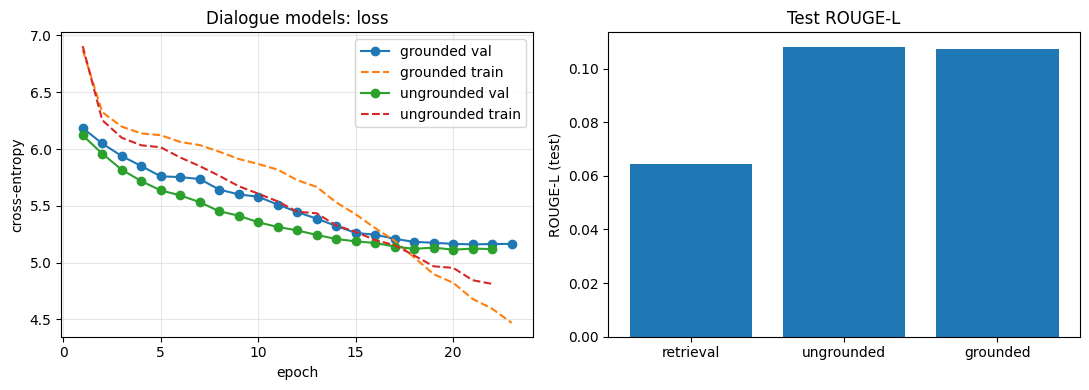

saved: ['dlg_g.pt', 'dlg_u.pt', 's3_results.json', 's3_results.png']


In [8]:
import matplotlib.pyplot as plt
g = np.random.default_rng(3); pick = g.choice(len(EX["test"]), 6, replace=False)
for i in pick:
    e = EX["test"][i]; title = docs[e["doc_key"][0]]["0"]["movieName"]
    print("MOVIE:", title, "| section", e["doc_key"][1]); print("HISTORY  :", " ".join(e["hist"])[-150:]); print("REFERENCE:", " ".join(e["tgt"]))
    for k in ("retrieval", "ungrounded", "grounded"): print("%-10s:" % k.upper(), " ".join(gen[k][i])); print()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for log, name in ((log_g, "grounded"), (log_u, "ungrounded")):
    a = np.array(log); ax[0].plot(a[:, 0], a[:, 3], marker="o", label=name + " val"); ax[0].plot(a[:, 0], a[:, 2], linestyle="--", label=name + " train")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy"); ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_title("Dialogue models: loss")
names = ["retrieval", "ungrounded", "grounded"]; ax[1].bar(names, [rows[k]["ROUGE_L"] for k in names]); ax[1].set_ylabel("ROUGE-L (test)"); ax[1].set_title("Test ROUGE-L")
plt.tight_layout(); plt.savefig(f"{WORK}/s3_results.png", dpi=150, bbox_inches="tight"); plt.show()
json.dump({"test": rows, "log_grounded": log_g, "log_ungrounded": log_u, "swap": sw}, open(f"{WORK}/s3_results.json", "w"))
print("saved:", sorted(f for f in os.listdir(WORK) if f.startswith("s3_") or f.startswith("dlg_")))

In [9]:
for name, log in (("grounded", log_g), ("ungrounded", log_u)):
    b = min(log, key=lambda r: r[3])
    print(name, "| epochs run", len(log), "| best epoch", b[0], "| best val loss %.3f | perplexity %.1f | train loss at the best epoch %.3f" % (b[3], b[4], b[2]))

cm = np.array(ENC["test"]["cm"]); q1, q2 = np.quantile(cm, [1 / 3, 2 / 3])
groups3 = {"lowest third (most Hindi-heavy)": np.where(cm <= q1)[0], "highest third (most English-heavy)": np.where(cm >= q2)[0]}
print("terciles of the proxy on test: %.2f and %.2f" % (q1, q2))
for name, idx in groups3.items():
    print(name, "| examples:", len(idx), "| proxy range %.2f to %.2f" % (cm[idx].min(), cm[idx].max()))
    for k, v in gen.items():
        s = score(v, "test", idx); print("   %-10s BLEU %.2f | ROUGE-L %.3f" % (k, s["BLEU"], s["ROUGE_L"]))

keys = [e["doc_key"] for e in EX["test"]]
for k, v in list(gen.items()) + [("reference", [e["tgt"] for e in EX["test"]])]:
    cw = [content(h) for h in v]
    found = sum(sum(t in set(doc_tokens[key]) for t in c) for c, key in zip(cw, keys)); total = sum(len(c) for c in cw)
    print("%-10s replies with at least one content word: %.1f%% | content words per reply: %.2f | share of content words found in the document: %.3f" % (
        k, 100 * np.mean([len(c) > 0 for c in cw]), total / len(v), found / max(total, 1)))

for k in ("retrieval", "ungrounded", "grounded"):
    c = collections.Counter(" ".join(h) for h in gen[k])
    print(k, "| distinct replies: %d of %d | most common:" % (len(c), len(gen[k])), c.most_common(3))

grounded | epochs run 23 | best epoch 21 | best val loss 5.161 | perplexity 174.3 | train loss at the best epoch 4.680
ungrounded | epochs run 22 | best epoch 20 | best val loss 5.114 | perplexity 166.3 | train loss at the best epoch 4.954
terciles of the proxy on test: 0.20 and 0.37
lowest third (most Hindi-heavy) | examples: 341 | proxy range 0.00 to 0.20
   retrieval  BLEU 0.33 | ROUGE-L 0.064
   ungrounded BLEU 0.88 | ROUGE-L 0.106
   grounded   BLEU 0.69 | ROUGE-L 0.110
highest third (most English-heavy) | examples: 313 | proxy range 0.37 to 1.00
   retrieval  BLEU 0.38 | ROUGE-L 0.064
   ungrounded BLEU 0.79 | ROUGE-L 0.099
   grounded   BLEU 0.71 | ROUGE-L 0.098
retrieval  replies with at least one content word: 87.1% | content words per reply: 3.65 | share of content words found in the document: 0.057
ungrounded replies with at least one content word: 2.8% | content words per reply: 0.03 | share of content words found in the document: 0.000
grounded   replies with at least one 